# Context-target sensitivity

Compares majority-label construction with tie exclusion and consistent-label restriction.

**Scope:** consumes registered artifacts; no model refitting is performed in this publication notebook.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT = Path.cwd().resolve().parents[1] if Path.cwd().name == 'publication' else Path.cwd().resolve()
if not (PROJECT / '05_results').exists():
    PROJECT = Path('outputs/CBAC-D-26-03155_revision/06_canonical_revision_project').resolve()
PRIOR = PROJECT.parent / '04_reproducible_analysis/artifacts'
PUB = PROJECT / '05_results/validated/publication_outputs'
TABLES, FIGURES = PUB / 'tables', PUB / 'figures'
TABLES.mkdir(parents=True, exist_ok=True); FIGURES.mkdir(parents=True, exist_ok=True)

def read_csv(path, required):
    assert path.exists(), f'Missing registered artifact: {path}'
    df = pd.read_csv(path)
    missing = set(required) - set(df.columns)
    assert not missing, f'{path.name}: missing columns {sorted(missing)}'
    return df

plt.rcParams.update({'figure.dpi': 130, 'savefig.dpi': 300, 'font.size': 9,
                     'axes.spines.top': False, 'axes.spines.right': False})
SPLIT_ORDER = ['exact', 'cluster', 'temporal']


In [2]:
src=PROJECT/'05_results/validated/context_label_sensitivity'
m=read_csv(src/'metrics.csv',['construction','split','model','pr_auc'])
d=read_csv(src/'paired_differences_vs_sequence.csv',['construction','split','model_a','difference_a_minus_b','ci_low','ci_high'])
c=read_csv(src/'construction_summary.csv',['construction','rows','excluded_rows','ties_remaining','mixed_label_rows_remaining'])
target='sequence_plus_all_no_evidence'
u=d[d.model_a.eq(target)].copy(); assert len(u)==9
out=m[m.model.eq(target)][['construction','split','pr_auc']].merge(u[['construction','split','difference_a_minus_b','ci_low','ci_high']],on=['construction','split'])
out.to_csv(TABLES/'table_03_context_sensitivity.csv',index=False); c.to_csv(TABLES/'table_03b_context_constructions.csv',index=False)
display(out); display(c)

,construction,split,pr_auc,difference_a_minus_b,ci_low,ci_high
0,majority_all,exact,0.770711,0.236118,0.205448,0.266254
1,majority_all,cluster,0.754739,0.254352,0.217641,0.292937
2,majority_all,temporal,0.487361,0.047250,0.022421,0.072468
3,majority_excluding_ties,exact,0.787706,0.231592,0.201101,0.263046
4,majority_excluding_ties,cluster,0.778487,0.259191,0.221151,0.297782
5,majority_excluding_ties,temporal,0.526828,0.059900,0.033190,0.085383
6,consistent_labels_only,exact,0.791355,0.235316,0.203095,0.267123
7,consistent_labels_only,cluster,0.782300,0.271643,0.233511,0.311546
8,consistent_labels_only,temporal,0.528368,0.065643,0.035089,0.093696


,construction,rows,excluded_rows,unique_peptides,positive_rate,ties_remaining,mixed_label_rows_remaining
0,majority_all,20785,0,17332,0.300361,662,1087
1,majority_excluding_ties,20123,662,16899,0.310242,0,425
2,consistent_labels_only,19698,1087,16676,0.306579,0,0


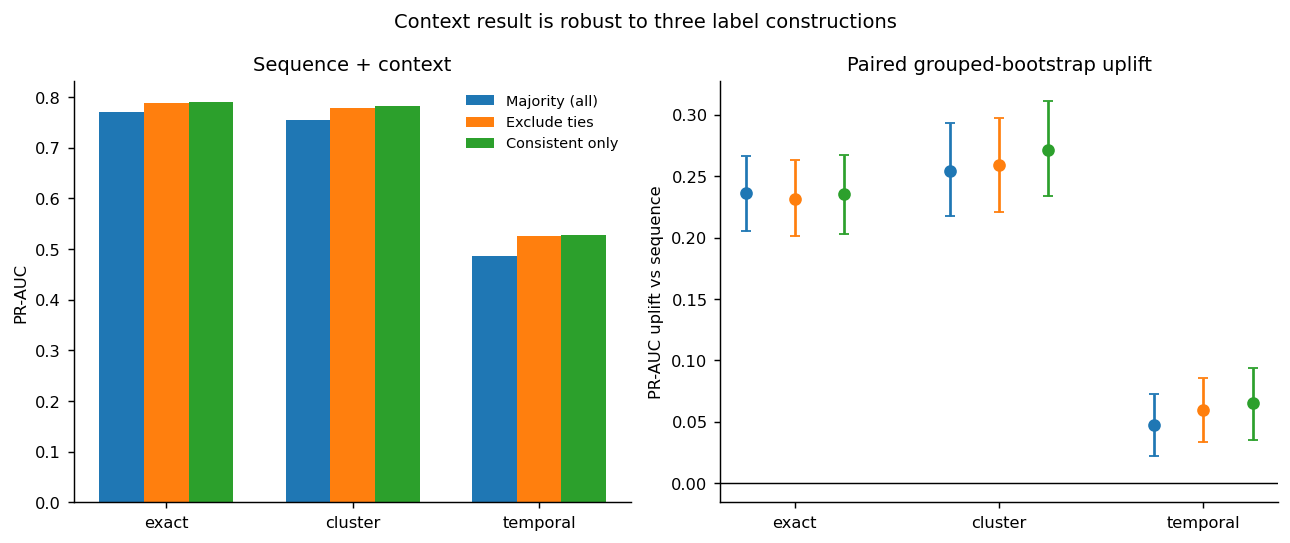

In [3]:
labels={'majority_all':'Majority (all)','majority_excluding_ties':'Exclude ties','consistent_labels_only':'Consistent only'}
fig,axs=plt.subplots(1,2,figsize=(10,4.2)); x=np.arange(3); width=.24
for j,(key,label) in enumerate(labels.items()):
 q=out[out.construction.eq(key)].set_index('split').loc[SPLIT_ORDER]
 axs[0].bar(x+(j-1)*width,q.pr_auc,width,label=label)
 y=q.difference_a_minus_b.to_numpy(); axs[1].errorbar(x+(j-1)*width,y,yerr=np.vstack([y-q.ci_low,q.ci_high-y]),fmt='o',capsize=3,label=label)
axs[0].set_xticks(x,SPLIT_ORDER); axs[0].set_ylabel('PR-AUC'); axs[0].set_title('Sequence + context')
axs[1].axhline(0,color='black',lw=.8); axs[1].set_xticks(x,SPLIT_ORDER); axs[1].set_ylabel('PR-AUC uplift vs sequence'); axs[1].set_title('Paired grouped-bootstrap uplift')
axs[0].legend(frameon=False,fontsize=8); fig.suptitle('Context result is robust to three label constructions'); fig.tight_layout(); fig.savefig(FIGURES/'figure_02_context_sensitivity.png'); plt.show()

**Interpretation.** Excluding tied outcomes or all mixed-label peptide contexts does not remove the uplift and slightly increases temporal estimates. This is a robustness check of a database-derived prediction target—not evidence that assay metadata causally improves biological immunogenicity.